In [1]:
import random

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [2]:
df = pd.read_csv("../data/raw/ealaxi/paysim1/PS_20174392719_1491204439457_log.csv", skiprows=lambda i: i > 0 and random.random() > 0.01)
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,1915.43,C822087264,11450.00,9534.57,M30699728,0.00,0.0,0,0
1,1,PAYMENT,2278.19,C1887699190,290.00,0.00,M1479140596,0.00,0.0,0,0
2,1,PAYMENT,7600.57,C1805164661,50747.00,43146.43,M778162712,0.00,0.0,0,0
3,1,PAYMENT,7870.29,C1202220987,1445223.63,1437353.34,M256346753,0.00,0.0,0,0
4,1,CASH_OUT,9864.23,C2142893855,0.00,0.00,C1254526270,15207.22,0.0,0,0


In [3]:
df.size

702130

Transaction Counts:
isFraud
0    63190
1       76
Name: count, dtype: int64


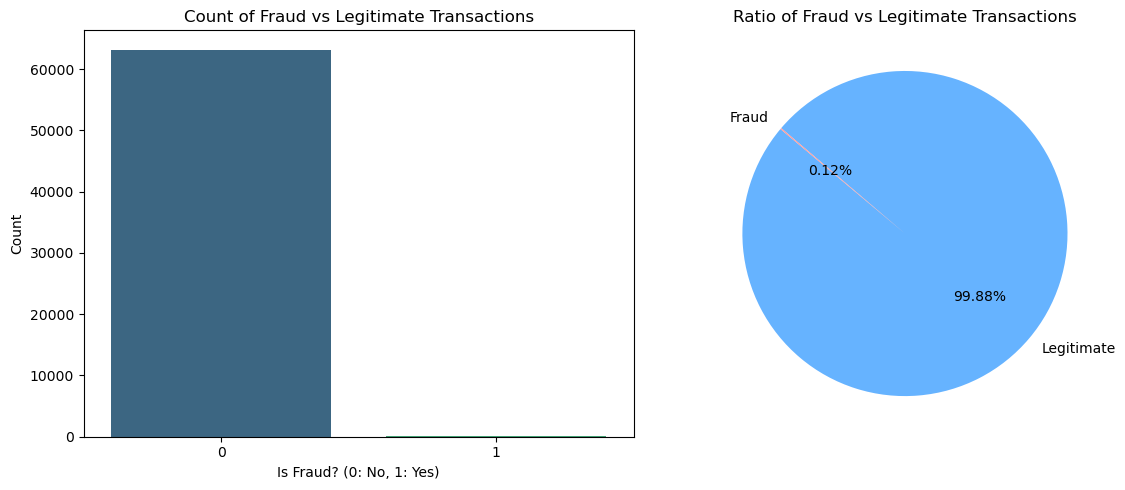

In [3]:

# Calculate the counts of each class
fraud_counts = df['isFraud'].value_counts()
print(f"Transaction Counts:\n{fraud_counts}")
# Create the visualizations
plt.figure(figsize=(12, 5))
# Plot 1: Bar Chart (Volume)
plt.subplot(1, 2, 1)
sns.barplot(x=fraud_counts.index, y=fraud_counts.values, palette='viridis', legend=False, hue=fraud_counts.index)
plt.title('Count of Fraud vs Legitimate Transactions')
plt.xlabel('Is Fraud? (0: No, 1: Yes)')
plt.ylabel('Count')
# Plot 2: Pie Chart (Ratio)
plt.subplot(1, 2, 2)
plt.pie(fraud_counts, labels=['Legitimate', 'Fraud'], autopct='%1.2f%%', startangle=140, colors=['#66b3ff','#ff9999'])
plt.title('Ratio of Fraud vs Legitimate Transactions')
plt.tight_layout()
plt.show()

Transaction Type Summary:
       type  total_transactions  fraud_cases  fraud_percentage
0   CASH_IN               13864            0          0.000000
1  CASH_OUT               22336           36          0.161175
2     DEBIT                 426            0          0.000000
3   PAYMENT               21343            0          0.000000
4  TRANSFER                5297           40          0.755144


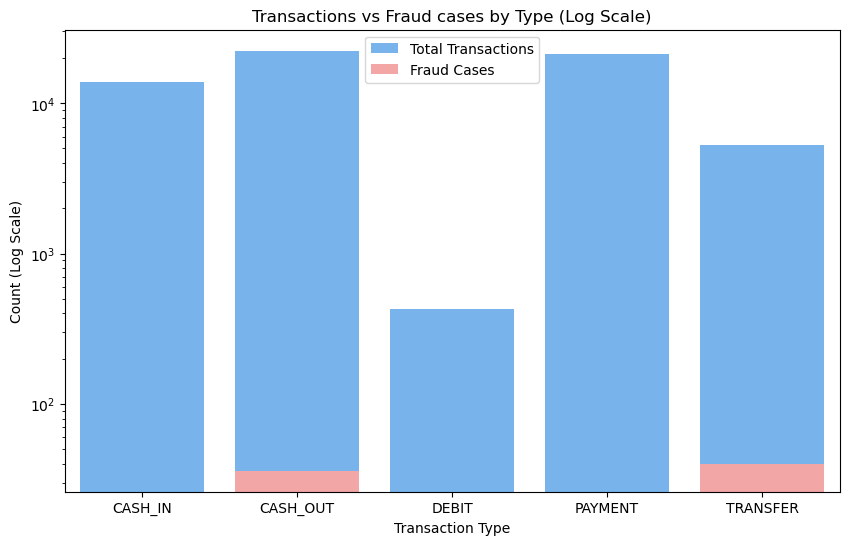

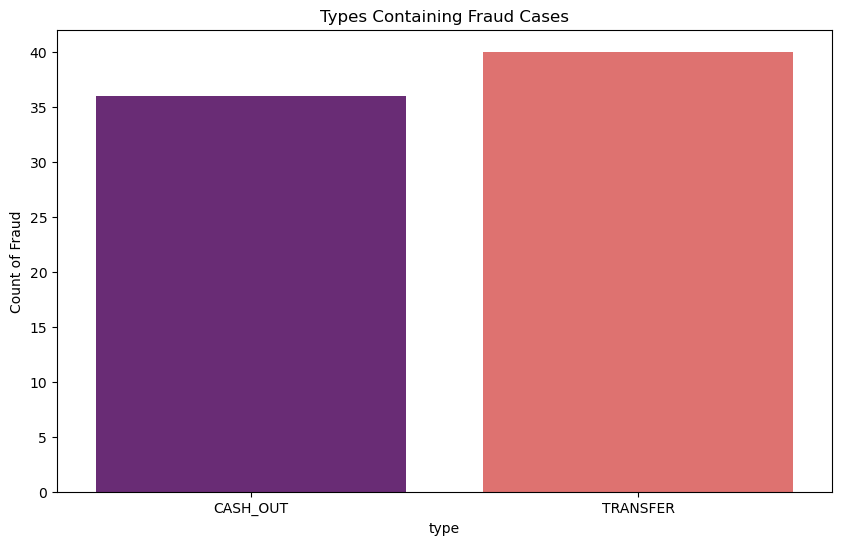

In [4]:
## 2. Transaction Type Filtering
# Group by type to see where the fraud cases are occurring
type_summary = df.groupby('type')['isFraud'].agg(['count', 'sum']).reset_index()
type_summary.columns = ['type', 'total_transactions', 'fraud_cases']

# Calculate fraud percentage for insight
type_summary['fraud_percentage'] = (type_summary['fraud_cases'] / type_summary['total_transactions']) * 100

print("Transaction Type Summary:")
print(type_summary)

# Visualization: Total Transactions vs Fraud Cases (Stacked)
plt.figure(figsize=(10, 6))

# We use a log scale because legitimate transactions usually dwarf fraud cases
ax = sns.barplot(data=type_summary, x='type', y='total_transactions', color='#66b3ff', label='Total Transactions')
sns.barplot(data=type_summary, x='type', y='fraud_cases', color='#ff9999', label='Fraud Cases')

ax.set_yscale("log") # Log scale makes the small fraud counts visible
plt.title('Transactions vs Fraud cases by Type (Log Scale)')
plt.xlabel('Transaction Type')
plt.ylabel('Count (Log Scale)')
plt.legend()
plt.show()

# Specific view: Only the fraud cases
plt.figure(figsize=(10, 6))
sns.barplot(
    data=type_summary[type_summary['fraud_cases'] > 0],
    x='type',
    y='fraud_cases',
    hue='type',
    palette='magma',
    legend=False
)
plt.title('Types Containing Fraud Cases')
plt.ylabel('Count of Fraud')
plt.show()


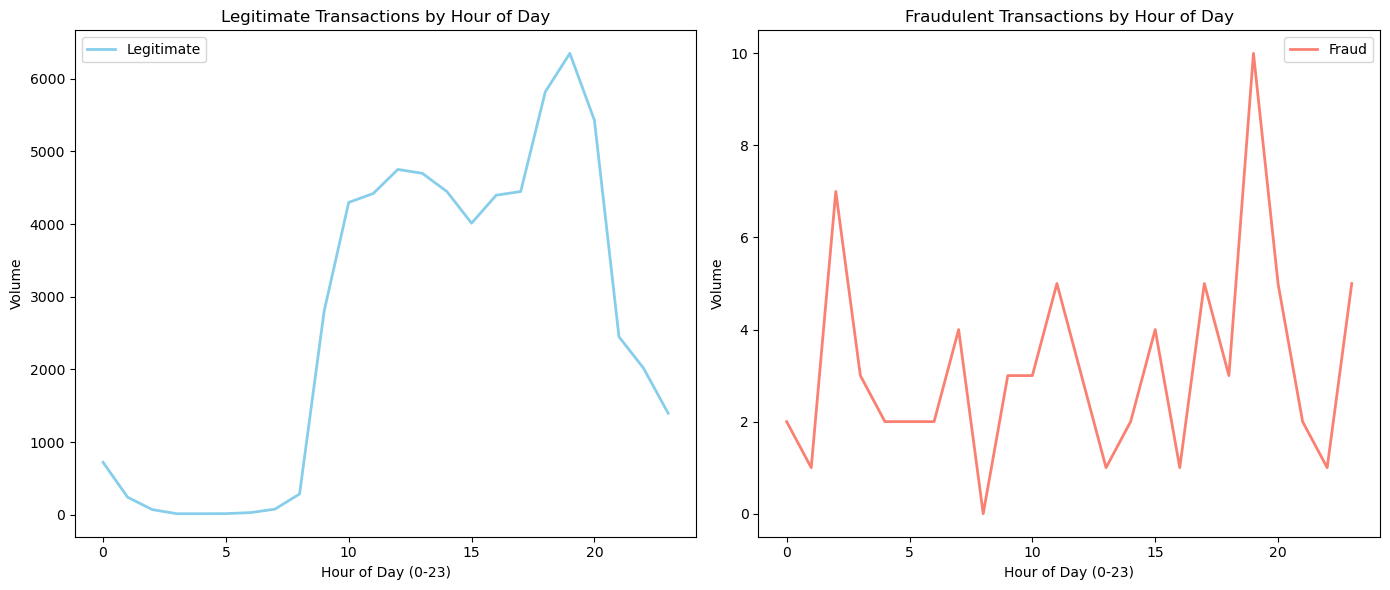

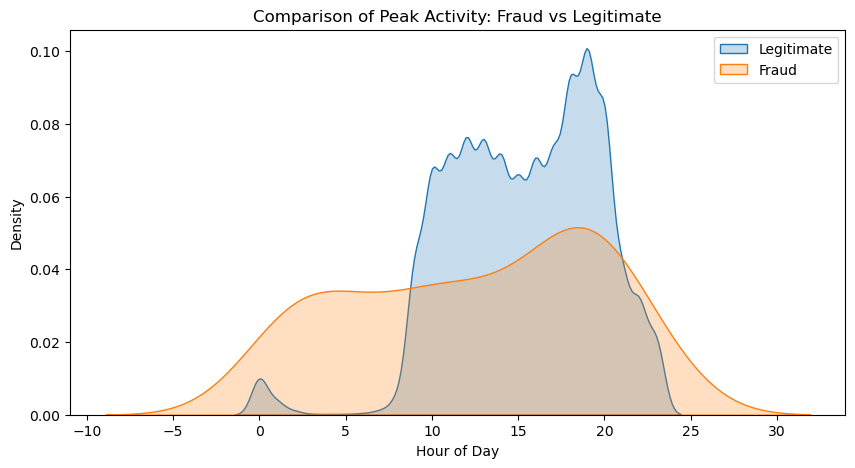

In [5]:
## 3. Temporal Patterns (The "Step" Feature)
# Feature Engineering: Extract hour of day
# step 1 is hour 1, so step % 24 gives us the hour (roughly)
df['hour_of_day'] = df['step'] % 24

# Grouping by hour to see volumes
hourly_counts = df.groupby(['hour_of_day', 'isFraud']).size().unstack(fill_value=0)

plt.figure(figsize=(14, 6))

# Plot 1: Legitimate Transaction Volume
plt.subplot(1, 2, 1)
sns.lineplot(data=hourly_counts[0], label='Legitimate', color='skyblue', linewidth=2)
plt.title('Legitimate Transactions by Hour of Day')
plt.xlabel('Hour of Day (0-23)')
plt.ylabel('Volume')

# Plot 2: Fraud Transaction Volume
plt.subplot(1, 2, 2)
sns.lineplot(data=hourly_counts[1], label='Fraud', color='salmon', linewidth=2)
plt.title('Fraudulent Transactions by Hour of Day')
plt.xlabel('Hour of Day (0-23)')
plt.ylabel('Volume')

plt.tight_layout()
plt.show()

# Alternative: Overlayed Normalized Volume to see peak alignment
plt.figure(figsize=(10, 5))
sns.kdeplot(df[df['isFraud'] == 0]['hour_of_day'], label='Legitimate', fill=True, bw_adjust=1)
sns.kdeplot(df[df['isFraud'] == 1]['hour_of_day'], label='Fraud', fill=True, bw_adjust=1)
plt.title('Comparison of Peak Activity: Fraud vs Legitimate')
plt.xlabel('Hour of Day')
plt.legend()
plt.show()


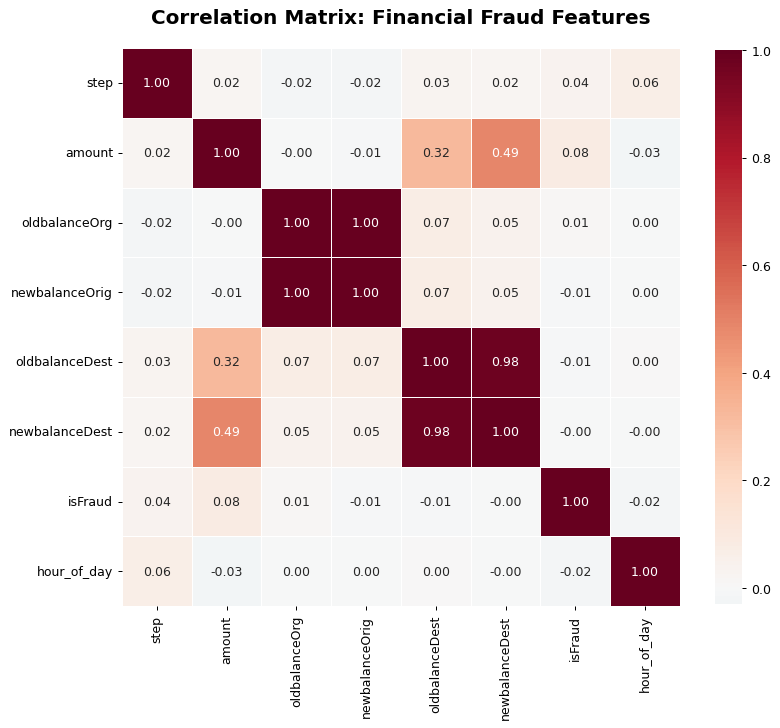

In [6]:
# 1. Prepare numeric data (filtering out constant columns)
df_numeric = df.select_dtypes(include=['number'])
df_numeric = df_numeric.loc[:, df_numeric.nunique() > 1]

# 2. Compute correlation matrix
corr = df_numeric.corr()

# 3. Plot modern, premium aesthetic heatmap
plt.figure(figsize=(10, 10), dpi=90)
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap='RdBu_r',
    center=0,
    square=True,
    linewidths=.5,
    cbar_kws={"shrink": .8}
)

plt.title('Correlation Matrix: Financial Fraud Features', fontsize=16, fontweight='bold', pad=20)
plt.show()


/home/shan-qing/miniconda3/envs/prac_mlops/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026/02/27 21:57:09 INFO mlflow.tracking.fluent: Experiment with name 'Fraud_Detection_EDA' does not exist. Creating a new experiment.


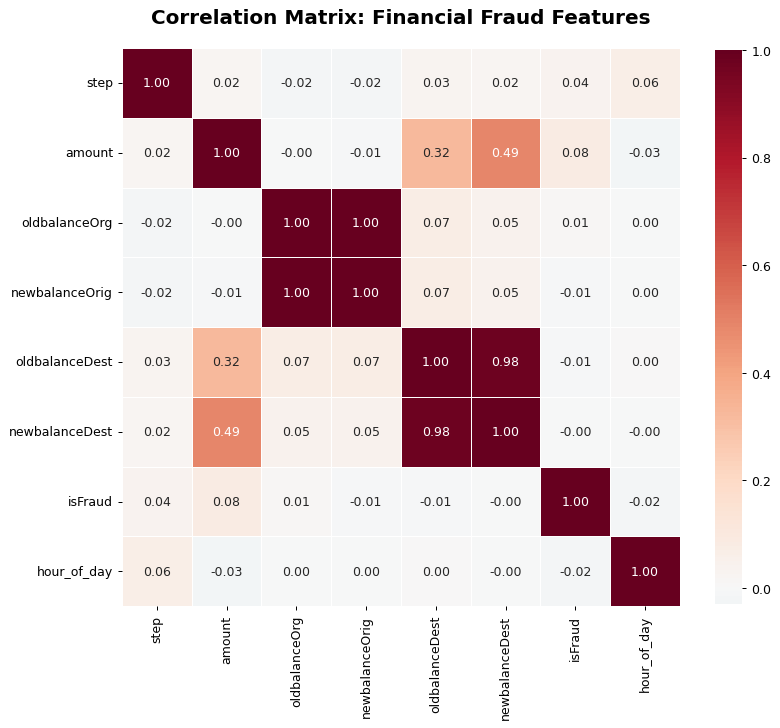

In [7]:
import matplotlib.pyplot as plt
import mlflow
import seaborn as sns

# 1. Ensure your tracking URI points to your SQLite DB
mlflow.set_experiment("Fraud_Detection_EDA")

with mlflow.start_run(run_name="Correlation_Analysis"):
    # --- Your Existing Plotting Code ---
    corr = df_numeric.corr()
    fig, ax = plt.subplots(figsize=(10, 10), dpi=90) # Create fig/ax objects

    sns.heatmap(
        corr,
        annot=True,
        fmt=".2f",
        cmap='RdBu_r',
        center=0,
        square=True,
        linewidths=.5,
        cbar_kws={"shrink": .8},
        ax=ax # Direct Seaborn to the specific axis
    )

    plt.title('Correlation Matrix: Financial Fraud Features', fontsize=16, fontweight='bold', pad=20)

    # --- 2. Log the figure to MLflow ---
    # This saves the 'fig' object as a PNG in your artifacts folder
    mlflow.log_figure(fig, "eda/correlation_matrix.png")

    # Optional: Log the raw correlation values as a CSV for deep dive later
    corr.to_csv("correlation_matrix.csv")
    mlflow.log_artifact("correlation_matrix.csv", artifact_path="eda/raw_data")

    plt.show()